# How Pose Extraction Works in `test_osl_extraction.py`

This notebook explains the process used in the `test_osl_extraction.py` script to extract human pose keypoints from OSL sign language videos using the RTMLib library.

## 1. Load Video Files and Labels

- The script loads a list of OSL sign language videos (MP4 files).
- It also loads the Arabic word labels from `Words.txt` to map each video to its corresponding sign.

In [1]:
from pathlib import Path

OSL_WORDS_PATH = Path(r'C:/Users/MOBPC/Downloads/FYP/Dataset/dataset/OSL-Words/rgb_format')
WORDS_LABELS_PATH = Path(r'C:/Users/MOBPC/Downloads/FYP/Dataset/Words.txt')

# Load labels
labels = {}
with open(WORDS_LABELS_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        parts = line.strip().split(' ', 1)
        if len(parts) == 2:
            labels[parts[0]] = parts[1]

# List first 5 videos
videos = sorted(OSL_WORDS_PATH.glob('*.mp4'))[:5]
for v in videos:
    video_id = v.stem.split('_')[0]
    print(f'{v.name} → {labels.get(video_id, "Unknown")[:10]}...')

0001_S01_T01.mp4 → مستشفى...
0002_S01_T01.mp4 → عيادة...
0003_S01_T01.mp4 → صيدلية...
0004_S01_T01.mp4 → طبيب...
0005_S01_T01.mp4 → ممرضة...


## 2. Initialize RTMLib Pose Extractor

- The script uses the `Wholebody` class from RTMLib to extract 133 keypoints (body, hands, face) from each frame.
- RTMLib is initialized to use the ONNX backend and CUDA (GPU) if available.

In [2]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), 'demo', 'rtmlib-main'))
from rtmlib import Wholebody

wholebody = Wholebody(to_openpose=False, mode='lightweight', backend='onnxruntime', device='cuda')
print('RTMLib Wholebody initialized!')

load C:\Users\MOBPC\.cache\rtmlib\hub\checkpoints\yolox_tiny_8xb8-300e_humanart-6f3252f9.onnx with onnxruntime backend
load C:\Users\MOBPC\.cache\rtmlib\hub\checkpoints\rtmw-dw-l-m_simcc-cocktail14_270e-256x192_20231122.onnx with onnxruntime backend
RTMLib Wholebody initialized!


## 3. Extract Poses from Video Frames

- For each video, the script samples frames (e.g., every 2nd or 3rd frame).
- Each frame is passed to the RTMLib pose extractor.
- The output is a set of keypoints (x, y coordinates for each joint) and confidence scores.
- The script counts how many frames had successful pose detections.

In [3]:
import cv2
import numpy as np

for video_path in videos:
    video_id = video_path.stem.split('_')[0]
    label = labels.get(video_id, 'Unknown')
    cap = cv2.VideoCapture(str(video_path))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f'\nVideo: {video_path.name} | Label: {label}')

    keypoints_list = []
    frames_with_poses = 0

    for frame_idx in range(0, min(total_frames, 30), 2):
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = cap.read()
        if not ret:
            break
        keypoints, scores = wholebody(frame)
        keypoints_list.append(keypoints)
        if scores is not None and np.any(scores > 0.3):
            frames_with_poses += 1

    cap.release()
    print(f'  Processed: {len(keypoints_list)} frames | Poses detected: {frames_with_poses}')
    if keypoints_list and keypoints_list[0] is not None:
        print(f'  Keypoints shape: {keypoints_list[0].shape}')
        print(f'  Sample keypoints (first 3):')
        for i in range(3):
            x, y = keypoints_list[0][0, i, 0], keypoints_list[0][0, i, 1]
            print(f'    Joint {i}: ({x:.1f}, {y:.1f})')


Video: 0001_S01_T01.mp4 | Label: مستشفى
  Processed: 15 frames | Poses detected: 15
  Keypoints shape: (1, 133, 2)
  Sample keypoints (first 3):
    Joint 0: (1014.1, 268.8)
    Joint 1: (1054.8, 222.7)
    Joint 2: (970.8, 233.5)

Video: 0002_S01_T01.mp4 | Label: عيادة
  Processed: 15 frames | Poses detected: 15
  Keypoints shape: (1, 133, 2)
  Sample keypoints (first 3):
    Joint 0: (1071.2, 248.4)
    Joint 1: (1110.2, 206.6)
    Joint 2: (1023.9, 223.3)

Video: 0003_S01_T01.mp4 | Label: صيدلية
  Processed: 15 frames | Poses detected: 15
  Keypoints shape: (1, 133, 2)
  Sample keypoints (first 3):
    Joint 0: (1055.4, 256.2)
    Joint 1: (1094.7, 214.2)
    Joint 2: (1007.7, 228.2)

Video: 0004_S01_T01.mp4 | Label: طبيب
  Processed: 15 frames | Poses detected: 15
  Keypoints shape: (1, 133, 2)
  Sample keypoints (first 3):
    Joint 0: (1057.5, 262.7)
    Joint 1: (1096.5, 229.3)
    Joint 2: (1013.0, 234.8)

Video: 0005_S01_T01.mp4 | Label: ممرضة
  Processed: 15 frames | Poses d

## 4. Summary

- RTMLib successfully extracts pose keypoints from OSL sign language videos.
- The extracted data (133 keypoints per frame) is compatible with the Uni-Sign model and WLASL pipeline.
- This process can be used for all videos in the dataset for training or inference.

## 5. Visualize Pose Keypoints on Video Frames

Let's draw the detected keypoints and skeleton on a sample frame from one of the OSL videos. This helps verify that pose extraction is working visually.

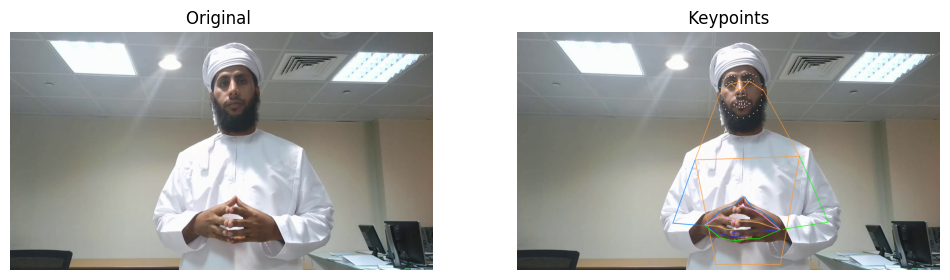

In [6]:
import matplotlib.pyplot as plt
from rtmlib.visualization.draw import draw_skeleton

# Pick the first video and extract a frame
video_path = videos[0]
cap = cv2.VideoCapture(str(video_path))
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
ret, frame = cap.read()
cap.release()

# Extract keypoints for the first frame
keypoints, scores = wholebody(frame)

# Draw skeleton on the frame
frame_with_skeleton = draw_skeleton(frame.copy(), keypoints, scores)

# Show the original and skeleton frame
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.title('Original ')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(frame_with_skeleton, cv2.COLOR_BGR2RGB))
plt.title(' Keypoints ')
plt.axis('off')
plt.show()